In [50]:
# 导入模块
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel
import seaborn as sns
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [ ]:
# 绘图函数
def get_TSPN_feature(model, signal):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
        x = model.feature_extractor_layers(signal)
    return x

def plot_violin_suda(model, test_signal, signal_num_list, feature_num):
    feature_name_list = ['均值', '标准差', '方差', '熵','最大值', '最小值', '绝对值均值', '峰度', '均方根值', '峰值因子','偏度', '间隙因子', '形状因子','全部特征']
    plt.rcParams['font.family'] = 'SimHei'
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    fault_type_list = ['正常', '缺滚珠', '花键螺母卡滞', '螺旋螺母卡滞']
    feature_list = []
    for signal_num in signal_num_list:
        feature = get_TSPN_feature(model, test_signal)[signal_num,:]
        if feature_num < 13:
            feature = feature[13*feature_num:13*(feature_num+1)]
        feature_list.append(feature.detach().cpu().numpy())
        # print(feature.shape)
        # break
    # 画小提琴图
    plt.figure(figsize=(10, 6))
    plt.title(feature_name_list[feature_num])
    sns.set_style('darkgrid')
    sns.violinplot(data=feature_list)
    plt.xticks(ticks = [0, 1, 2, 3], labels=fault_type_list)
    plt.xlabel("故障类型")
    plt.grid()
    plt.savefig('save/figure/suda/'+feature_name_list[feature_num]+'_violin.svg')

def plot_violin_hust(model, test_signal, signal_num_list, feature_num):
    feature_name_list = ['Mean', 'Std', 'Var', 'Entropy','Max', 'Min', 'AbsMean', 'Kurtosis', 'RMS', 'CrestFactor','Skewness', 'ClearanceFactor', 'ShapeFactor','All']
    fault_type_list = ['Norm','Inner Fault','Outer Fault','Ball Fault','Combination Fault']
    feature_list = []
    for signal_num in signal_num_list:
        feature = get_TSPN_feature(model, test_signal)[signal_num,:]
        if feature_num < 13:
            feature = feature[12*feature_num:12*(feature_num+1)]
        feature_list.append(feature.detach().cpu().numpy())
        # print(feature.shape)
        # break
    # 画小提琴图
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.figure(figsize=(10, 6))
    plt.title(feature_name_list[feature_num])
    sns.set_style('darkgrid')
    sns.violinplot(data=feature_list)
    plt.xticks(ticks = [0, 1, 2, 3, 4], labels=fault_type_list)
    plt.xlabel("fault type")
    plt.grid()
    plt.savefig('save/figure/feature/'+feature_name_list[feature_num]+'_violin.svg')

def plot_violin_hust_ori(model, test_signal, signal_num_list, feature_num):
    feature_name_list = ['Mean', 'Std', 'Var', 'Entropy','Max', 'Min', 'AbsMean', 'Kurtosis', 'RMS', 'CrestFactor','Skewness', 'ClearanceFactor', 'ShapeFactor','All']
    fault_type_list = ['Norm','Inner Fault','Outer Fault','Ball Fault','Combination Fault']
    feature_list = []
    
    for signal_num in signal_num_list:
        ori_signal = test_signal[signal_num,:,:]
        ori_signal = ori_signal.T
        feature_all = []
        i = 0
        for feature_operator in model.feature_extractor_modules:
            feature = model.feature_extractor_modules[feature_operator](ori_signal).view(-1)
            # print(feature.shape)
            if feature_num < 13 and feature_num == i:
                feature_list.append(feature.detach().cpu().numpy())
            for f in feature:
                feature_all.append(f.item())
            i += 1
        if feature_num == 13:
            feature_list.append(np.array(feature_all))
            

        # break
        # if feature_num < 13:
        #     feature = feature[12*feature_num:12*(feature_num+1)]
        # feature_list.append(feature.detach().cpu().numpy())
        # print(feature.shape)
        # break
    # 画小提琴图
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.figure(figsize=(10, 6))
    plt.title(feature_name_list[feature_num])
    sns.set_style('darkgrid')
    sns.violinplot(data=feature_list)
    plt.xticks(ticks = [0, 1, 2, 3, 4], labels=fault_type_list)
    plt.xlabel("fault type")
    plt.grid()
    plt.savefig('save/figure/feature/'+feature_name_list[feature_num]+'_violin_ori.svg')

## HUST model

In [52]:
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_031_HUST/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_tson_hust_20hz.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)

Running experiment: model_TSPNtime09-19-38-22_datasetHUST_031_Basic_it0
# build signal processing layers
# build feature extractor layers
# build classifier


C:\Users\CCSLab\AppData\Local\Temp\ipykernel_7892\1588059976.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("./save/test/model_tson_hust_20hz.c

<All keys matched successfully>

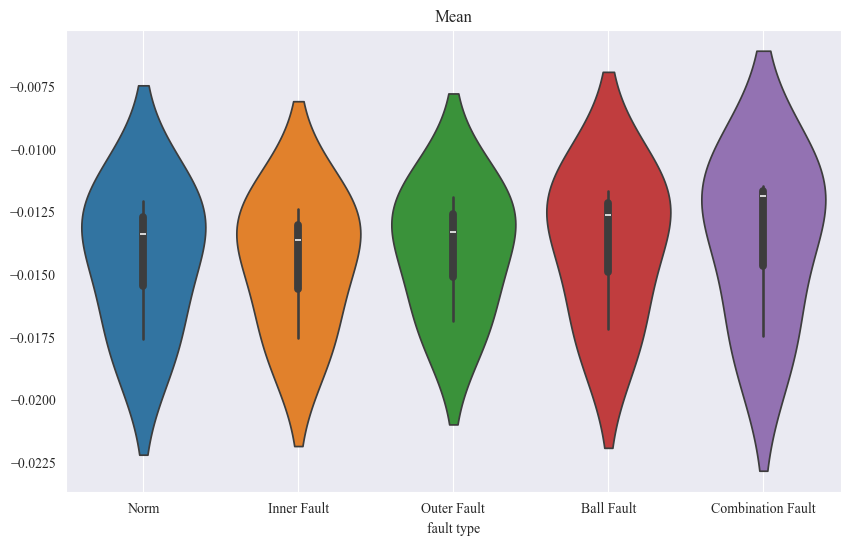

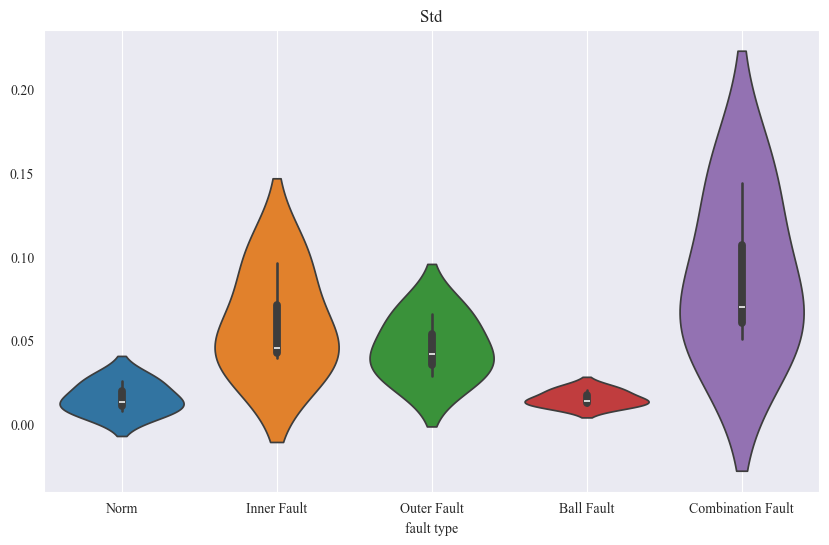

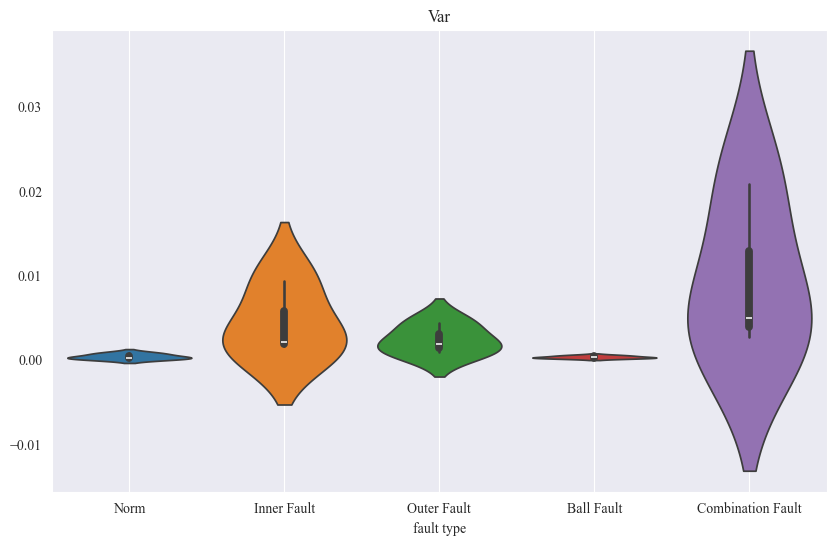

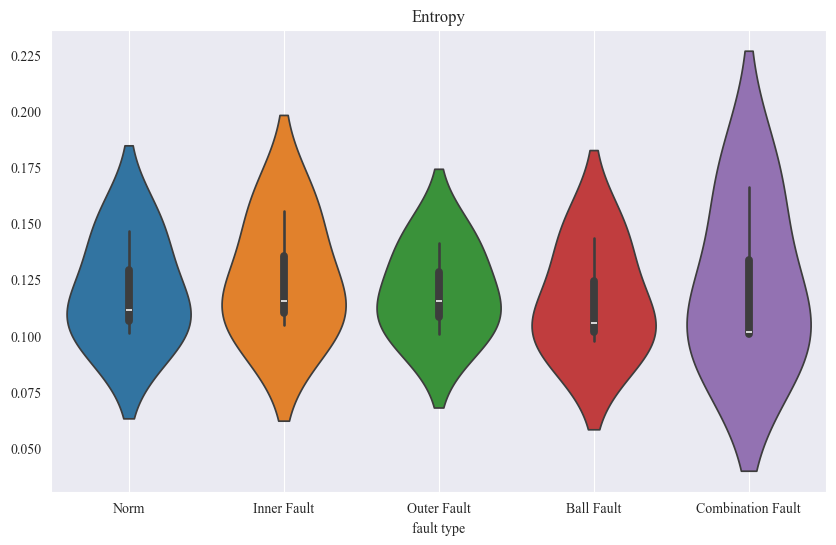

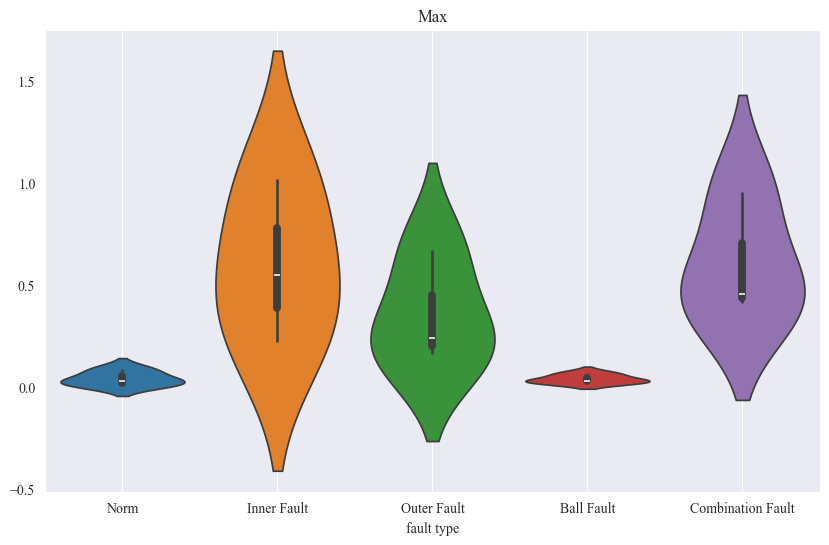

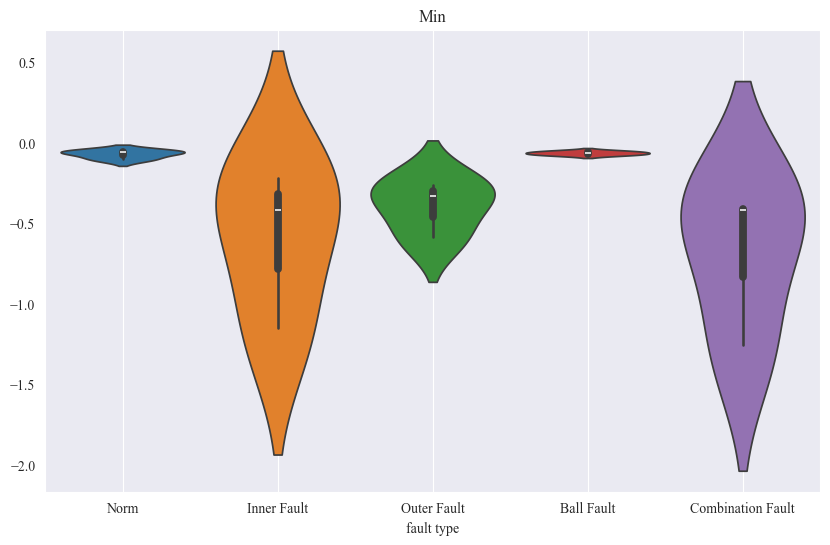

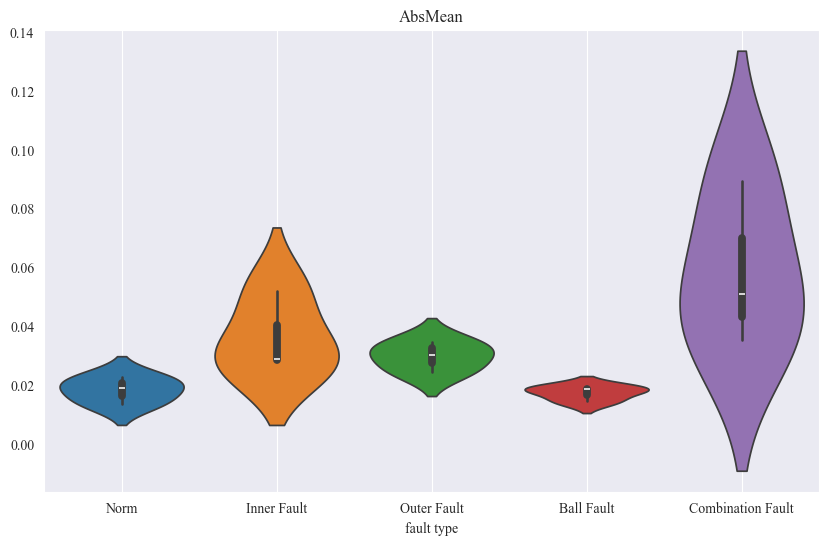

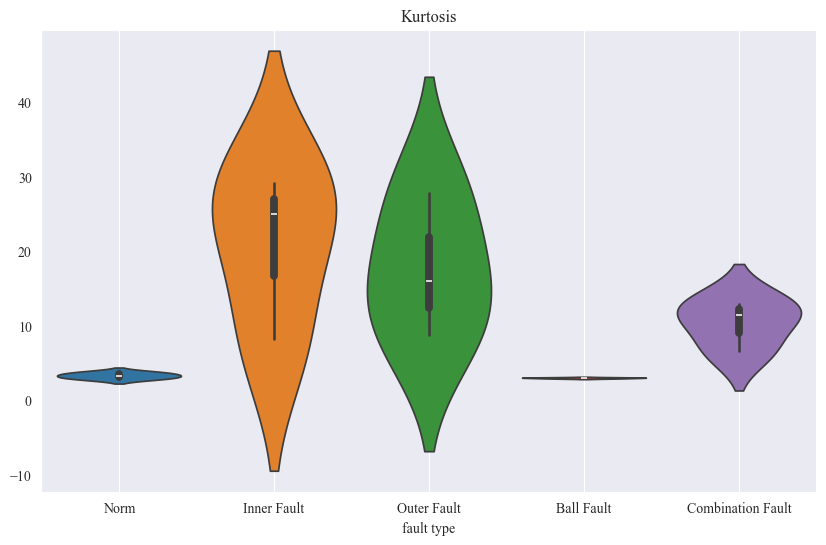

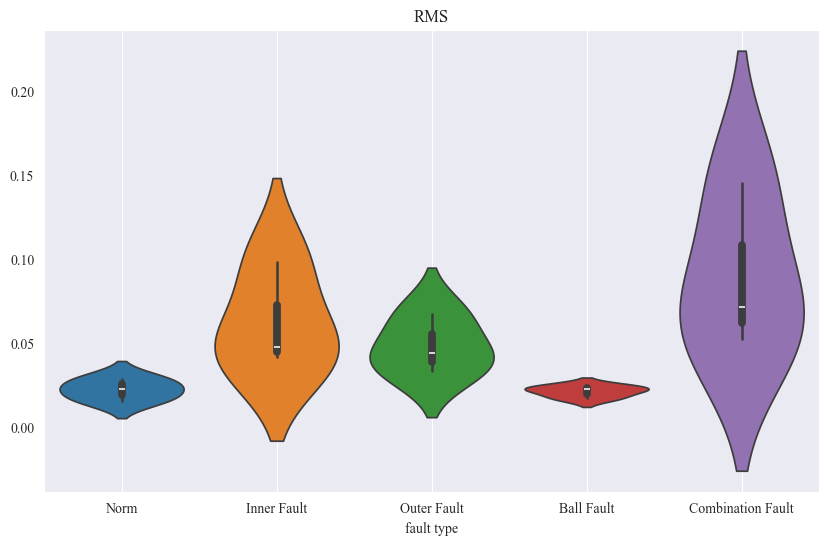

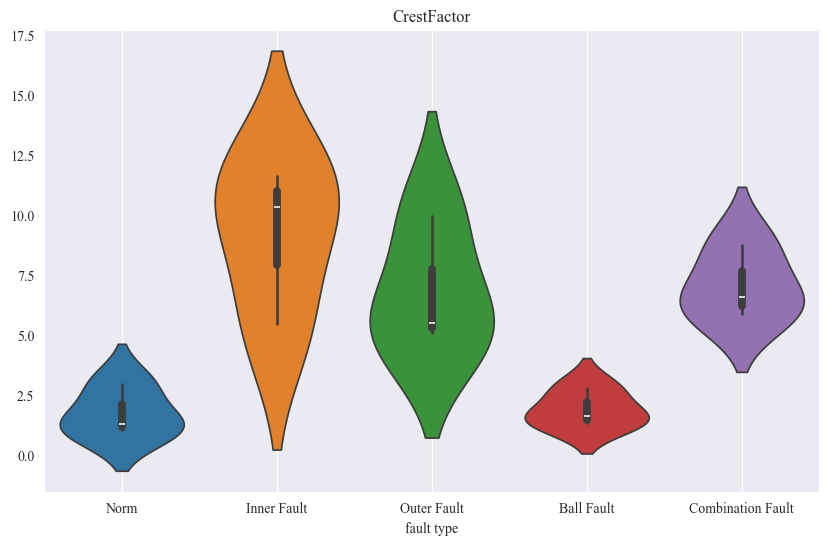

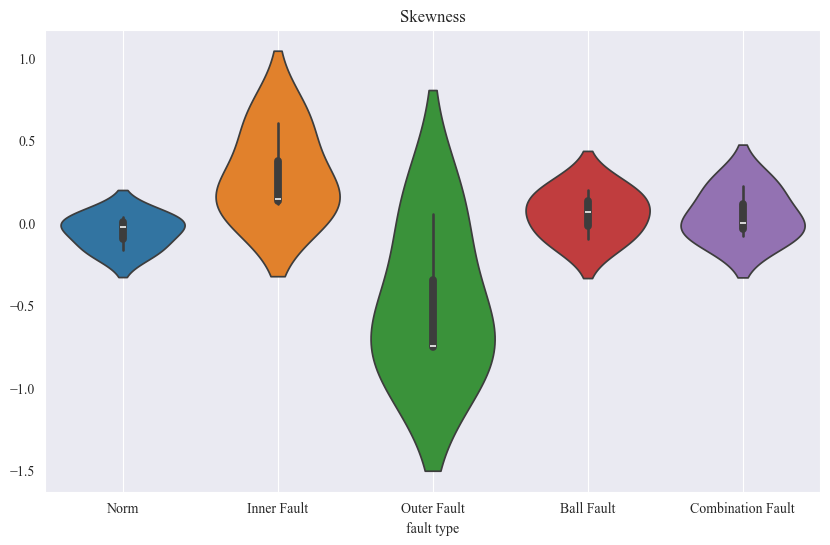

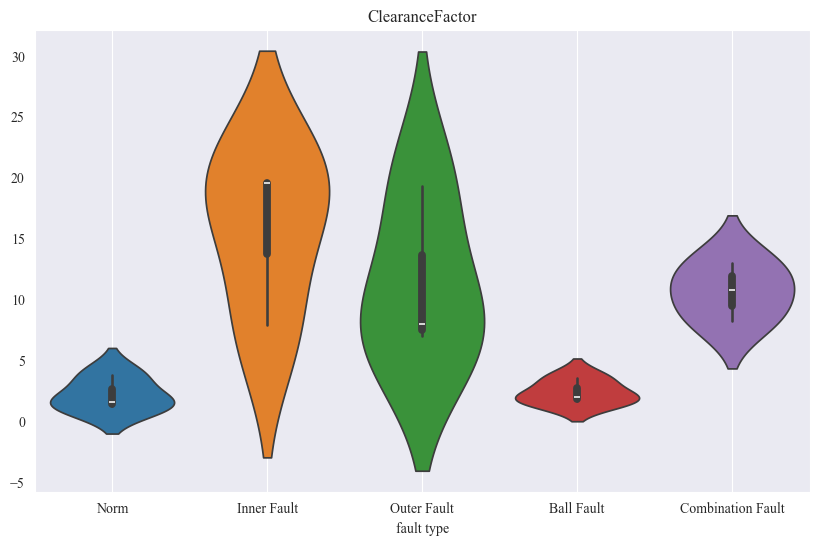

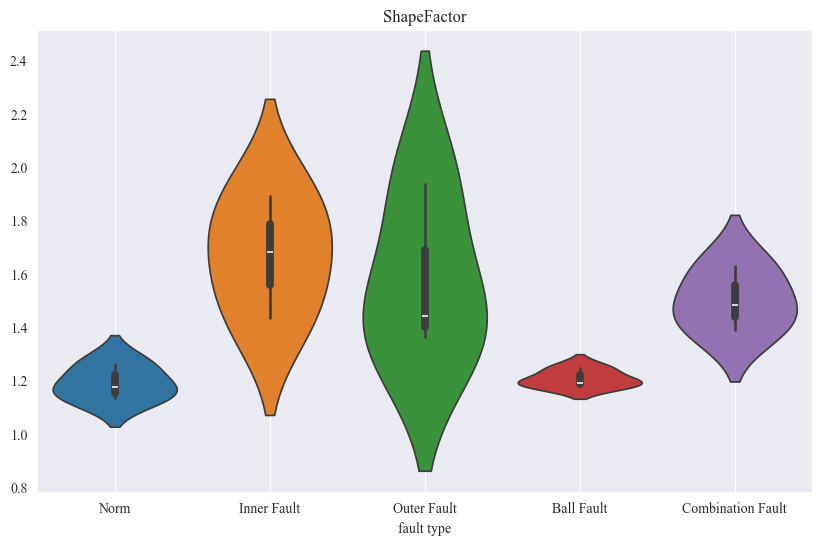

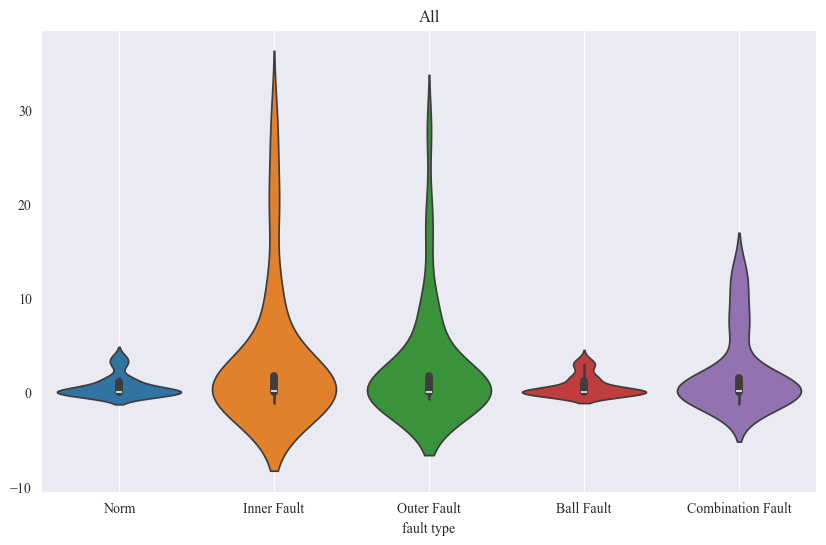

In [61]:
test_data = np.load("C:/Users/CCSLab/Desktop/HUST_bearing/HUST_bearing_20Hz_data.npy")
test_signal = torch.from_numpy(test_data).cuda().float()
signal_num_list = [10, 100, 200, 350, 480]
for i in range(14):
    plot_violin_hust_ori(model.network.cuda(), test_signal, signal_num_list, i)
    # plot_violin_hust(model.network.cuda(), test_signal, signal_num_list, i)

## suda model

In [ ]:
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_temp_SUDA_electric/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_tspn_suda_01.ckpt")
model.load_state_dict(state_dict['state_dict'])
print(model)

In [ ]:
test_data = np.load("C:/Users/CCSLab/Desktop/SUDA_electric/SUDA_electric_0kg_2500r_1000Hz_data.npy")
test_signal = torch.from_numpy(test_data).cuda().float()
signal_num_list = [110, 160, 10, 60]
for i in range(14):
    plot_violin_suda(model.network.cuda(),test_signal, signal_num_list, i)